<a href="https://colab.research.google.com/github/DineshSBhauryal/streamlit-app/blob/main/IIT_M_LangGraph_in_Detail_by_Vinay_Kumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Graphs

SME(Trainer) : Vinay Kumar (vinay2k2@gmail.com)<br>
Connect with me:
https://www.linkedin.com/in/vinay2k2


## Step 1 — Hello World (Single Node Graph)

**Concept** - A graph with just one node.

**Story**: - Our assistant only greets the user.

### Python and no Langgraph world

{
  "chief_complaint": {
    "text": null,
    "confidence": null
  },
  "symptoms": [],
  "signs": [],
  "diagnosis": [],
  "medications": [],
  "metadata": {
    "patient_age": null,
    "patient_gender": null
  }
}

In [ ]:
from typing import TypedDict, List
# State Definition
class State(TypedDict):
    name: str # stores the user's name
    message: str # stores the greeting message generated by the node

In [ ]:
# Node
def greet_user(state: State):  #sum(number1:int)
    name = state["name"]
    # print(state["message"])
    # state[message] ="Hello {name}, welcome to today's class!"
    # return state
    return {"message": f"Hello {name}, welcome to today's class!"}

In [ ]:
# We can call the function directly
greet_user({"name": "John", "message": "Hello"})

{'message': "Hello John, welcome to today's class!"}

### Langgraph starts here

In [ ]:
!pip install langgraph langchain

In [ ]:
from langgraph.graph import StateGraph, END

In [ ]:
# Graph
builder = StateGraph(State) # Create a StateGraph object using the State schema.

builder.add_node("greet", greet_user) # Add a node named "greet" that runs the greet_user function

# Define the starting point of the graph execution
builder.set_entry_point("greet")
builder.add_edge("greet", END) # Define the flow: after "greet" node runs, go to END
# builder.set_finish_point("greet")
graph = builder.compile() # Compile the graph so it becomes executable

In [ ]:
graph.invoke({"name": "John"})

{'name': 'John', 'message': "Hello John, welcome to today's class!"}

In [ ]:
# Run
name = input("Hey what shall I call you?")
result = graph.invoke({"name": name}) # Invoke the graph by passing the initial state
print(result) # Print the final state returned from the graph

Hey what shall I call you?vinay
{'name': 'vinay', 'message': "Hello vinay, welcome to today's class!"}


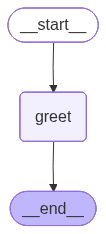

In [ ]:
# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### All combined

Hey what shall I call you?vinay
{'name': 'vinay', 'message': "Hello vinay, welcome to today's class!"}


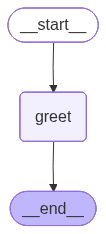

In [ ]:
# State Definition
class State(TypedDict):
    name: str # stores the user's name
    message: str # stores the greeting message generated by the node


# Node
def greet_user(state: State):
    name = state["name"]
    return {"message": f"Hello {name}, welcome to today's class!"}


# Graph
builder = StateGraph(State) # Create a StateGraph object using the State schema.

builder.add_node("greet", greet_user) # Add a node named "greet" that runs the greet_user function

builder.set_entry_point("greet") # Define the starting point of the graph execution

builder.add_edge("greet", END) # Define the flow: after "greet" node runs, go to END

graph = builder.compile() # Compile the graph so it becomes executable


# Run
name = input("Hey what shall I call you?")
result = graph.invoke({"name": name}) # Invoke the graph by passing the initial state
print(result) # Print the final state returned from the graph


# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Lets try writing it again from scratch with custom names

In [ ]:
class SS(TypedDict):
  name:str
  age: int
  old: str

In [ ]:
def age_greater(var_name:SS):
  if var_name["age"]>35:
    var_name["old"]="old"
    return var_name
  else:
    var_name["old"]="not Old"
    return var_name

In [ ]:
from langgraph.graph import StateGraph, END, START

In [ ]:
ss_builder = StateGraph(SS)

In [ ]:
ss_builder.add_node("age_greater", age_greater)

In [ ]:
ss_builder.set_entry_point("age_greater")

In [ ]:
ss_builder.set_finish_point("age_greater")

In [ ]:
graph_ss = ss_builder.compile()

In [ ]:
graph_ss.invoke({"age":40})

{'age': 40, 'old': 'old'}

In [ ]:
graph_ss.invoke({"name":"John","age":30})

{'name': 'John', 'age': 30, 'old': 'not Old'}

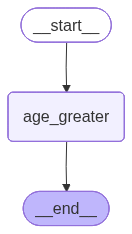

In [ ]:
from IPython.display import Image, display
display(Image(graph_ss.get_graph().draw_mermaid_png()))

### Step 2 — Sequential Workflow

Now the assistant becomes smarter.

**Workflow**
Greet → Get email id → Send Message

This introduces multiple nodes executed sequentially.

Hey what shall I call you?vinay
Please enter your email id: viny@gmail.com
{'name': 'vinay', 'email_id': 'viny@gmail.com', 'message': 'Hello vinay! Your email_id is viny@gmail.com'}


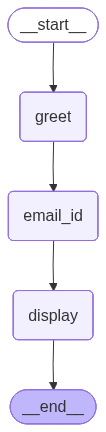

In [ ]:
# State
# A graph ensures flow of execution and it is exhibiting flow of data from one node to next. Data is flowing through shared state read and write.
# A graph must have START, END and one execution/processing node
class State(TypedDict): # Define the structure of the state
    name: str # vinay
    email_id: str #vinay@gmail.com
    message: str  # Hello vinay ---> # Hello vinay Your email_id is vinay@gmail.com


# Nodes # functions used in the graph

# Node 1: Greets the user using their name
def greet_user(state: State):
    return {"message": f"Hello {state['name']}!"} # # Hello vinay
    #After this state is
    '''
    name: str # vinay
    email_id: str
    message: str  # Hello vinay
    '''

# Node 2: Asks the user to enter their email id
def get_email_id(state: State):
    email = input("Please enter your email id: ") #vinay@gmail.com
    return {"email_id": email}
    #After this state is
    '''
    name: str # vinay
    email_id: str #vinay@gmail.com
    message: str  # Hello vinay
    '''


# Node 3: Displays the final message with name and email
def display_message(state: State):
    msg = f"{state['message']} Your email_id is {state['email_id']}" # Hello vinay Your email_id is vinay@gmail.com
    return {"message": msg}
    #After this state is and this is the final stage so this is also final state of the dictionary
    '''
    name: str # vinay
    email_id: str #vinay@gmail.com
    message: str  # Hello vinay Your email_id is vinay@gmail.com
    '''


# Graph
builder = StateGraph(State) # Create a StateGraph using the State structure

# Add nodes to the graph
builder.add_node("greet", greet_user)
builder.add_node("email_id", get_email_id)
builder.add_node("display", display_message)

# Define where the graph starts
builder.set_entry_point("greet")

# Define how nodes connect to each other
builder.add_edge("greet", "email_id")
builder.add_edge("email_id", "display")
builder.add_edge("display", END)

# Compile the graph so it can run
graph = builder.compile()


# Run
name = input("Hey what shall I call you?")
result = graph.invoke({"name": name}) # Start the graph with the initial state
print(result)


# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### LangGraph – Minimum Requirements & Discussions
<br>




### What is actually required

A **LangGraph workflow** must have:

- **START node** – entry point  
- **END node** – termination point  
- **At least one processing node** (your actual logic)

The **START** and **END** nodes are **special virtual nodes** that define where execution begins and ends.  
They **do not run any code**.

---

### Typical minimal structure


START → processing_node → END


---

### Example

```python
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("process", process_fn) # We start by adding the processing node first

builder.add_edge(START, "process")
builder.add_edge("process", END)

graph = builder.compile()
```


**Important clarification:** You do **not** need exactly one execution node. You can have **many nodes between `START` and `END`.**

**Example:** `START → planner → search → summarize → END`

You can also add **conditional routing, loops, parallel branches,** and **multiple nodes leading to `END`.**

**Key rules:**  
- `START` must exist and **cannot have incoming edges**  
- `END` must exist and **cannot have outgoing edges**  
- **All execution paths should eventually reach `END`**

**Correct interpretation:**  
- `START` and `END` are **required boundaries**  
- You need **at least one real node**, but you **can have many**

**Minimal graph mental model:**  
`Entry → Workflow steps → Exit`  
`START → nodes (1..N) → END`  

**Not just:**  
`START → one node → END`

## Curosity Boosters:Can we have Multiple State Variables, one for User one  for course and so on, isn't it better to keep them separate

### Curosity Boosters:Can we have Multiple State Variables, one for User, one for course and so on, isn't it better to keep them separate? <br>

Can we have two states like this in a graph getting managed <br>

```
from typing import TypedDict

class UserState(TypedDict):
    name: str
    age: int

class CourseState(TypedDict):
    course: str
```



🧠 Key Idea (Important)

In LangGraph:

👉 You only define ONE State schema <br>
👉 But that state can contain multiple fields (variables)<br>
👉 And each node updates different parts of that same state<br>

So what you wrote is already a multi-variable state, not multiple separate states.<br>
<br>
❓ Can we have multiple State classes?<br>
<br>
🚫 No (in a single graph)<br>
StateGraph(State) only accepts one schema<br>

✅ How to simulate “multiple states”<br>

Instead of multiple classes, you structure it like this:
<br>
✔ Option 1: Grouped fields (recommended)

```
from typing import TypedDict

class UserState(TypedDict):
    name: str
    age: int

class CourseState(TypedDict):
    course: str

class State(TypedDict):
    user: UserState
    course_info: CourseState
    message: str
```
✔ Nodes using different parts

```
def greet_user(state: State):
    return {
        "message": f"Hello {state['user']['name']}!"
    }

def add_course_details(state: State):
    return {
        "message": state["message"] + f" You are enrolled in {state['course_info']['course']}."
    }
✔ Run
result = graph.invoke({
    "user": {"name": "Vinay", "age": 22},
    "course_info": {"course": "AI"}
})
```


<br>

🧩 Option 2: Think of it like a “shared memory object”
<br>
Instead of:
<br>
State1 → State2 → State3
<br>
LangGraph does:
<br>
ONE State (shared)<br>
   ├── name<br>
   ├── age<br>
   ├── course<br>
   ├── message<br>
   └── anything else<br>
<br>
Each node just updates part of it.
<br>
🔥 If you REALLY want separate states
<br><br>
**You have 3 advanced options:**
<br>
1. Multiple graphs
<br>
Each graph has its own State
<br>
You chain graphs manually
<br>
2. Subgraphs (advanced LangGraph)
<br>
Each subgraph can have its own structure
<br>
Parent graph still manages overall state
<br>
💡 Best Practice
<br>
Use one state + structured fields like:
<br>


```
class State(TypedDict):
    input: dict
    intermediate: dict
    output: dict
```
🚀 Simple Mental Model
<br>
Think of LangGraph state like:
<br>
👉 a single JSON object flowing through nodes
<br>
Example:
```
{
  "name": "Vinay",
  "age": 22,
  "course": "AI",
  "message": "Hello Vinay!"
}
```
<br>
Each node just edits this JSON.

### Can we try Anything Else?

### Nesting?
## 🧠 Key Idea
- Still **ONE state**
- But organized into **nested objects**
- Cleaner and scalable for real-world systems



✅ Final Output:
{'user': {'name': 'Vinay', 'age': 22}, 'course': 'AI', 'message': 'Hello Vinay! You are 22 years old and enrolled in AI.'}


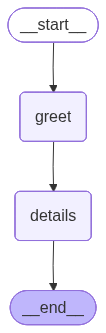

In [ ]:
# =========================
# 🧩 State Definition (Nested)
# =========================
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
class UserState(TypedDict):
    name: str
    age: int


# class Course(TypedDict):
#     name: str
#     age: int

# class UserState(TypedDict):
#     name: str
#     age: int


class State(TypedDict):
    user: UserState
    course: str
    message: str

# =========================
# ⚙️ Nodes
# =========================
def greet_user(state: State):
    return {
        "message": f"Hello {state['user']['name']}!"
    }

def add_details(state: State):
    return {
        "message": state["message"] +
        f" You are {state['user']['age']} years old and enrolled in {state['course']}."
    }

# =========================
# 🔗 Graph
# =========================
builder = StateGraph(State)

builder.add_node("greet", greet_user)
builder.add_node("details", add_details)

builder.set_entry_point("greet")
builder.add_edge("greet", "details")
builder.add_edge("details", END)

graph = builder.compile()

# =========================
# ▶️ Run
# =========================
result = graph.invoke({
    "user": {
        "name": "Vinay",
        "age": 22
    },
    "course": "AI"
})

print("\n✅ Final Output:")
print(result)

# =========================
# 📊 Visualization
# =========================
# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Step 3 — Multiple Inputs

Now the assistant asks the user for 2 alternative email ids.

Enter your name: vinay
Enter your primary email: vin@gmail.com

Enter two alternative email IDs
Alternative Email 1: vin1@gmail,com
Alternative Email 2: vin2@gmail.com

Registration Summary
Name: vinay
Primary Email: vin@gmail.com
Alternative Emails: ['vin1@gmail,com', 'vin2@gmail.com']


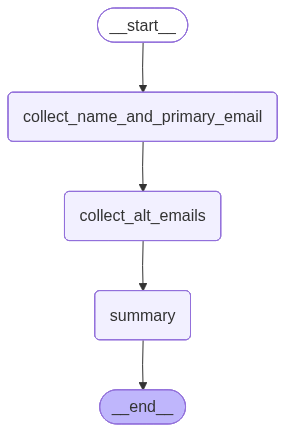

In [ ]:
# State
class State(TypedDict): # Define the structure of the state
    name: str # vinay
    primary_email: str # vinay@gmail.com
    alt_emails: List[str] # vina1@gmail.com, vin2@gmail.com


# Nodes

# Node 1: Collect user's name and primary email
def collect_name_and_primary_email(state: State):
    name = input("Enter your name: ")
    email = input("Enter your primary email: ")

    return {
        "name": name,
        "primary_email": email
    }


# Node 2: Collect two alternative email addresses
def collect_alternative_emails(state: State):
    print("\nEnter two alternative email IDs")

    email1 = input("Alternative Email 1: ")
    email2 = input("Alternative Email 2: ")

    return {
        "alt_emails": [email1, email2]
    }


# Node 3: Display a summary of the collected information
def summary(state: State):
    print("\nRegistration Summary")
    print("Name:", state["name"])
    print("Primary Email:", state["primary_email"])
    print("Alternative Emails:", state["alt_emails"])
    return state



# Graph

# Create a graph using the defined State structure
builder = StateGraph(State)

# Add nodes to the graph
builder.add_node("collect_name_and_primary_email", collect_name_and_primary_email)
builder.add_node("collect_alt_emails", collect_alternative_emails)
builder.add_node("summary", summary)

# Set the starting node of the graph
builder.set_entry_point("collect_name_and_primary_email")

# Define the flow between nodes
builder.add_edge("collect_name_and_primary_email", "collect_alt_emails")
builder.add_edge("collect_alt_emails", "summary")
builder.add_edge("summary", END)

# Compile the graph so it becomes executable
graph = builder.compile()


# Run
graph.invoke({})


# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Step 4 — Conditional Routing


---


Now the assistant check with user, if they want to enter their phone number:

If the user gives consent → gets number
If the user does not give consent → skips

Enter your name: vinay
Enter your email: vina@gmail,com
Do you wish to enter your phone number? (yes/no) no

Registration Summary
Name: vinay
Email: vina@gmail,com
Phone: Not Provided


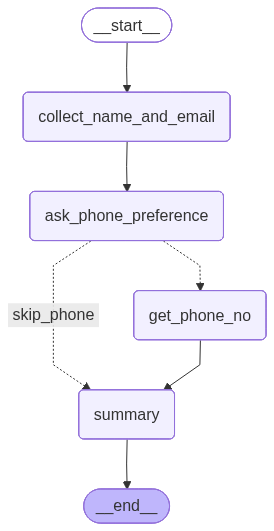

In [ ]:
# State
class State(TypedDict): # Define the structure of the state
    name: str # vinay
    email: str #  vina@gmail,com
    consent_phone: str # no
    phone_no: str



# Nodes
# Node 1: Collect user's name and email
def collect_name_and_email(state: State):
    name = input("Enter your name: ")
    email = input("Enter your email: ")

    return {
        "name": name,
        "email": email
    }


# Node 2: Ask user if they want to provide their phone number
def ask_phone_preference(state: State):
    consent = input("Do you wish to enter your phone number? (yes/no) ")
    return {"consent_phone": consent.lower()}


# Node 3: Collect phone number if user agreed
def get_phone_no(state: State):
    phone_no = input("Please enter your phone number: ")
    return {"phone_no": phone_no}


# Node 4: Display a summary of collected information
def summary(state: State):
    print("\nRegistration Summary")
    print("Name:", state["name"])
    print("Email:", state["email"])

    if state.get("phone_no"):
        print("Phone:", state["phone_no"])
    else:
        print("Phone: Not Provided")
    return state



# Condition Function
# Decides which node to go to next based on user's consent
def route_phone(state: State):

    if state["consent_phone"] == "yes":
        return "get_phone_no"

    return "skip_phone"



# Graph
builder = StateGraph(State)

# Add nodes to the graph
builder.add_node("collect_name_and_email", collect_name_and_email)
builder.add_node("ask_phone_preference", ask_phone_preference)
builder.add_node("get_phone_no", get_phone_no)
builder.add_node("summary", summary)

# Define the starting node
builder.set_entry_point("collect_name_and_email")

# Define flow between nodes
builder.add_edge("collect_name_and_email", "ask_phone_preference")


# Add conditional branching based on user's answer
builder.add_conditional_edges(
    "ask_phone_preference",
    route_phone,  # get_phone_no skip_phone
    {
        "get_phone_no": "get_phone_no", # builder.add_edge("ask_phone_preference", "get_phone_no")
        "skip_phone": "summary" # builder.add_edge("ask_phone_preference", "summary")
    }
)

# After collecting phone, move to summary
builder.add_edge("get_phone_no", "summary")

# End the graph after summary
builder.add_edge("summary", END)

# Compile the graph
graph = builder.compile()

# Run
graph.invoke({})

# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Run
graph.invoke({})

KeyboardInterrupt: Interrupted by user

## Step 5 — Looping Workflow

Now we build retry logic.

If the user enters phone number less than 10 digits, then ask again for valid number.

Please enter your phone number: 899808
Invalid Phone number, enter 10 digits...
Please enter your phone number: 232131
Invalid Phone number, enter 10 digits...
Please enter your phone number: 3123123
Invalid Phone number, enter 10 digits...
Please enter your phone number: 21312312
Invalid Phone number, enter 10 digits...
Please enter your phone number: 435234234
Invalid Phone number, enter 10 digits...
Please enter your phone number: 23432432
Invalid Phone number, enter 10 digits...
Please enter your phone number: 32423
Invalid Phone number, enter 10 digits...
Please enter your phone number: 1234567890
Valid Phone Number
{'phone_no': '1234567890'}


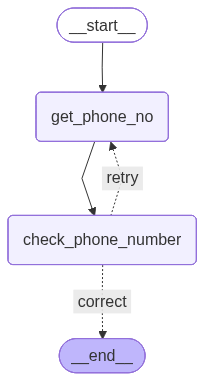

In [ ]:
# State
class State(TypedDict): # Define the structure of the state
    phone_no: int


# Nodes
# Node 1: Ask the user to enter their phone number
def get_phone_no(state: State):

    phone_no = input("Please enter your phone number: ")
    return {
        "phone_no": phone_no,
    }

# Node 2: Check whether the phone number is valid
def check_phone_number(state: State):

    if len(state["phone_no"]) == 10:
        print("Valid Phone Number")
    else:
        print("Invalid Phone number, enter 10 digits...")

    return state

# Condition
# Decides whether to end the graph or retry input
def should_continue(state: State):

    if len(state["phone_no"]) == 10:
        return "correct"
    else:
        return "retry"
    return state

# Graph
builder = StateGraph(State)

# Add nodes to the graph
builder.add_node("get_phone_no", get_phone_no)
builder.add_node("check_phone_number", check_phone_number)

# Define the starting node
builder.set_entry_point("get_phone_no")

# Define normal flow
builder.add_edge("get_phone_no","check_phone_number")

# Add conditional routing after validation
builder.add_conditional_edges(
    "check_phone_number",
    should_continue,
    {
        "correct": END,
        "retry": "get_phone_no"
    }
)

# Compile the graph
graph = builder.compile()


# Run
result = graph.invoke({})
print(result)


# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Simple Analogy for Students

LangGraph is like Google Maps for code.

Instead of writing:

function A <br>
function B <br>
function C <br>

You design routes between functions.

A → B → C <br>
A → D → C <br>
A → B → B → C <br>

This is why agent systems are built using graphs.

Powerful Closing Demo Idea (for class)

Lets see these progression visually.

Hello World → Single Node <br>
Sequential → Pipeline <br>
Multiple Inputs → Rich State <br>
Conditional → Decisions <br>
Loop → Agent Behavior <br>



## Combination

Enter your name: fdfd
Enter your email: dsadad
Do you want to provide your phone number? (yes/no): no

Enter two alternative email IDs
Alternative Email 1: sadsad
Alternative Email 2: sadsad

===== Registration Summary =====
Name: fdfd
Email: dsadad
None
Phone: Not Provided
Alternative Emails: ['sadsad', 'sadsad']

Final State:
{'name': 'fdfd', 'email': 'dsadad', 'consent_phone': 'no', 'alt_emails': ['sadsad', 'sadsad']}


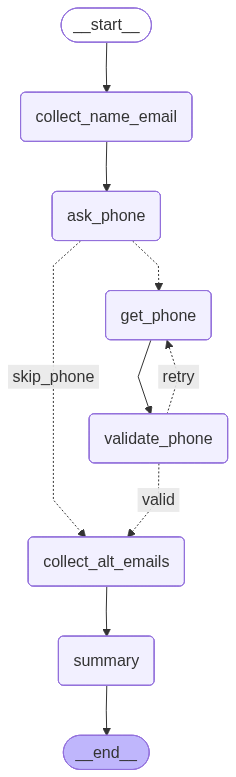

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END


# State
# Defines the structure of the state shared across nodes
class State(TypedDict):
    name: str
    email: str
    consent_phone: str
    phone_no: str
    alt_emails: List[str]


# Nodes
# Collect user's name and email
def collect_name_and_email(state: State):

    name = input("Enter your name: ")
    email = input("Enter your email: ")

    return {
        "name": name,
        "email": email
    }


# Ask user if they want to provide phone number
def ask_phone_preference(state: State):

    consent = input("Do you want to provide your phone number? (yes/no): ")

    return {
        "consent_phone": consent.lower()
    }


# Collect phone number
def get_phone_no(state: State):

    phone = input("Enter your phone number: ")

    return {
        "phone_no": phone
    }


# Validate phone number
def validate_phone(state: State):

    if len(state["phone_no"]) == 10:
        print("Valid Phone Number")
    else:
        print("Invalid phone number. Please try again.")

    return state


# Collect alternative emails
def collect_alt_emails(state: State):

    print("\nEnter two alternative email IDs")

    email1 = input("Alternative Email 1: ")
    email2 = input("Alternative Email 2: ")

    return {
        "alt_emails": [email1, email2]
    }


# Display final summary
def summary(state: State):

    print("\n===== Registration Summary =====")

    print("Name:", state["name"])
    print("Email:", state["email"])
    print(state.get("phone_no"))

    if state.get("phone_no"):
        print("Phone:", state["phone_no"])
    else:
        print("Phone: Not Provided")

    print("Alternative Emails:", state["alt_emails"])

    return state



# Condition
# Decide if phone step should run
def route_phone(state: State):

    if state["consent_phone"] == "yes":
        return "get_phone"

    return "skip_phone"

# Validate phone and decide next step
def validate_phone_route(state: State):

    if len(state["phone_no"]) == 10:
        return "valid"
    return "retry"

# Graph
builder = StateGraph(State)

# Add nodes
builder.add_node("collect_name_email", collect_name_and_email)
builder.add_node("ask_phone", ask_phone_preference)
builder.add_node("get_phone", get_phone_no)
builder.add_node("validate_phone", validate_phone)
builder.add_node("collect_alt_emails", collect_alt_emails)
builder.add_node("summary", summary)

# Entry point
builder.set_entry_point("collect_name_email")

# Normal flow
builder.add_edge("collect_name_email", "ask_phone")

# Conditional branch (phone optional)
builder.add_conditional_edges(
    "ask_phone",
    route_phone,
    {
        "get_phone": "get_phone",
        "skip_phone": "collect_alt_emails"
    }
)

# Phone validation flow
builder.add_edge("get_phone", "validate_phone")

builder.add_conditional_edges(
    "validate_phone",
    validate_phone_route,
    {
        "valid": "collect_alt_emails",
        "retry": "get_phone"
    }
)

# Continue flow
builder.add_edge("collect_alt_emails", "summary")
builder.add_edge("summary", END)

# Compile graph
graph = builder.compile()


# Run
result = graph.invoke({})

print("\nFinal State:")
print(result)



# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Enter your name: vinay
Enter your email: vinay@gmail.com
Do you want to provide your phone number? (yes/no): yes
Enter your phone number: 88888888
Invalid phone number. Please try again.
Enter your phone number: 89898989
Invalid phone number. Please try again.
Enter your phone number: 7889878897
Valid Phone Number

Enter two alternative email IDs
Alternative Email 1: vinay1@gmail.com
Alternative Email 2: vinay2@gmail.com

===== Registration Summary =====
Name: vinay
Email: vinay@gmail.com
Phone: 7889878897
Alternative Emails: ['vinay1@gmail.com', 'vinay2@gmail.com']

Final State:
{'name': 'vinay', 'email': 'vinay@gmail.com', 'consent_phone': 'yes', 'phone_no': '7889878897', 'alt_emails': ['vinay1@gmail.com', 'vinay2@gmail.com']}


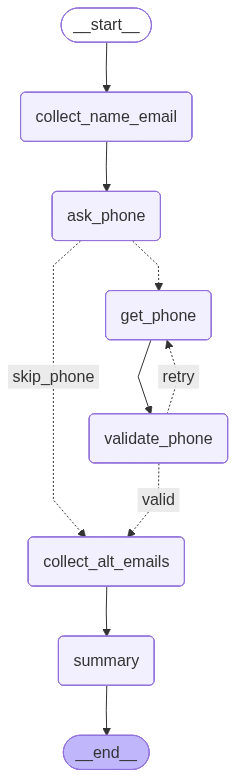

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END


# State
# Defines the structure of the state shared across nodes
class State(TypedDict):
    name: str
    email: str
    consent_phone: str
    phone_no: str
    alt_emails: List[str]


# Nodes
# Collect user's name and email
def collect_name_and_email(state: State):

    name = input("Enter your name: ")
    email = input("Enter your email: ")

    return {
        "name": name,
        "email": email
    }


# Ask user if they want to provide phone number
def ask_phone_preference(state: State):

    consent = input("Do you want to provide your phone number? (yes/no): ")

    return {
        "consent_phone": consent.lower()
    }


# Collect phone number
def get_phone_no(state: State):

    phone = input("Enter your phone number: ")

    return {
        "phone_no": phone
    }


# Validate phone number
def validate_phone(state: State):

    if len(state["phone_no"]) == 10:
        print("Valid Phone Number")
    else:
        print("Invalid phone number. Please try again.")

    return state


# Collect alternative emails
def collect_alt_emails(state: State):

    print("\nEnter two alternative email IDs")

    email1 = input("Alternative Email 1: ")
    email2 = input("Alternative Email 2: ")

    return {
        "alt_emails": [email1, email2]
    }


# Display final summary
def summary(state: State):

    print("\n===== Registration Summary =====")

    print("Name:", state["name"])
    print("Email:", state["email"])

    if state.get("phone_no"):
        print("Phone:", state["phone_no"])
    else:
        print("Phone: Not Provided")

    print("Alternative Emails:", state["alt_emails"])

    return state



# Condition
# Decide if phone step should run
def route_phone(state: State):

    if state["consent_phone"] == "yes":
        return "get_phone"

    return "skip_phone"


# Validate phone and decide next step
def validate_phone_route(state: State):

    if len(state["phone_no"]) == 10:
        return "valid"

    return "retry"


# Graph
builder = StateGraph(State)

# Add nodes
builder.add_node("collect_name_email", collect_name_and_email)
builder.add_node("ask_phone", ask_phone_preference)
builder.add_node("get_phone", get_phone_no)
builder.add_node("validate_phone", validate_phone)
builder.add_node("collect_alt_emails", collect_alt_emails)
builder.add_node("summary", summary)

# Entry point
builder.set_entry_point("collect_name_email")

# Normal flow
builder.add_edge("collect_name_email", "ask_phone")

# Conditional branch (phone optional)
builder.add_conditional_edges(
    "ask_phone",
    route_phone,
    {
        "get_phone": "get_phone",
        "skip_phone": "collect_alt_emails"
    }
)

# Phone validation flow
builder.add_edge("get_phone", "validate_phone")

builder.add_conditional_edges(
    "validate_phone",
    validate_phone_route,
    {
        "valid": "collect_alt_emails",
        "retry": "get_phone"
    }
)

# Continue flow
builder.add_edge("collect_alt_emails", "summary")
builder.add_edge("summary", END)

# Compile graph
graph = builder.compile()


# Run
result = graph.invoke({})

print("\nFinal State:")
print(result)



# Visualization
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

# Connecting Integrating LLM KB Tools Memory

## Building Chatbot

#### Configuration refer to Langchain Tutorial Code to get these

In [ ]:
!pip install -U langchain openai langchain-openai langchain_community tavily-python langsmith  wikipedia

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.9/132.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=88a0e24e03f30772c516ff618c9d4e101aa9362633ffa7d301bf621669385ed2
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia
  Attempting uninstall: requests
   

In [ ]:
from google.colab import userdata
# Required for model usage
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')
TAVILY_API_KEY=userdata.get('tavily_key')

In [ ]:
import os
from google.colab import userdata

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# Set your LangChain API key
os.environ["LANGCHAIN_API_KEY"] = userdata.get("langsmith_key")

# Enable Langsmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = "true"

# Set the Langsmith project name
os.environ["LANGCHAIN_PROJECT"] = "QC_Tutorial"

print("Environment variables set for OpenAI API Key, LangChain API Key, Langsmith Tracing, and Langsmith Project.")

Environment variables set for OpenAI API Key, LangChain API Key, Langsmith Tracing, and Langsmith Project.


In [ ]:
# Testing LLM Call via API
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")
llm.invoke("What is Agent?")

AIMessage(content='The term "agent" can have several meanings depending on the context in which it is used. Here are a few common interpretations:\n\n1. **In Business**: An agent is a person or entity authorized to act on behalf of another person or organization (the principal) to negotiate and sign contracts, handle transactions, or perform specific tasks.\n\n2. **In Technology/Computer Science**: An agent often refers to a software entity that can autonomously perform tasks or make decisions based on its environment. This is commonly seen in areas such as artificial intelligence, where an agent might operate within a system to analyze data and take actions accordingly.\n\n3. **In Legal Terms**: An agent can be someone who has the authority to represent someone else in legal or financial matters. For example, an attorney can act as an agent for their client.\n\n4. **In Literature and Cultural Studies**: An "agent" can refer to a character or a force that acts within a narrative, influ

In [ ]:
# Testing LLM Call via API for Agent Model Configuration
# https://docs.langchain.com/oss/python/integrations/chat
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-5-nano",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)

response = model.invoke("Tracing test")

In [ ]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in San Francisco?"}]}
)

{'messages': [HumanMessage(content='What is the weather in San Francisco?', additional_kwargs={}, response_metadata={}, id='6b9545d6-a2ce-46c6-8854-f2ad67a608bd'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 216, 'prompt_tokens': 142, 'total_tokens': 358, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DqFNNMbA6n8yQMY3TD2qS3XsE15sA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ec068-7a07-7b62-932c-7ba3249717b1-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'call_YU8XEixVMBiZkRh4m8LmyBNu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 14

### Lets Build the Agent Now.  

**L : LLM** <br>
M : Memory: Short Term, Long Term<br>
T : Tool : Local, API, MCP<br>
K : Knowledge Base: RAG<br>




In [ ]:
# ============================
# Imports
# ============================
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
# from dotenv import load_dotenv  # Loads environment variables like API keys
from langchain_openai import ChatOpenAI

# ============================
# Load environment variables if you need to
# ============================
# load_dotenv()


# ============================
# Define the State Schema
# ============================
class ConversationState(TypedDict):
    """
    This defines the structure of the data flowing through the graph.
    Here, we are maintaining a list of user messages.
    """
    messages: List[HumanMessage]

# ============================
# Initialize LLM
# ============================
chat_model = ChatOpenAI(model="gpt-4o-mini")

# ============================
# Node Logic (Core Processing)
# ============================
def generate_response(state: ConversationState) -> ConversationState:
    """
    This function acts as a node in the graph.
    It takes the current state, sends messages to the LLM,
    and prints the response.

    Note:
    - We are not modifying the state here.
    - This is a stateless interaction pattern.
    """
    result = chat_model.invoke(state["messages"])
    print("\nAssistant:", result.content)
    print("CURRENT STATE: ", state["messages"])

    return state  # Returning unchanged state
# ============================
# Build the Graph
# ============================
workflow = StateGraph(ConversationState)

# Add processing node
workflow.add_node("response_node", generate_response)

# Define execution flow
workflow.add_edge(START, "response_node")
workflow.add_edge("response_node", END)

# Compile the graph into an executable agent
compiled_agent = workflow.compile()

# ============================
# Interactive Loop
# ============================
def run_chat():
    """
    Simple CLI loop to interact with the agent.
    Type 'exit' to stop the conversation.
    """
    user_text = input("You: ")

    while user_text.lower() != "exit":
        compiled_agent.invoke({
            "messages": [HumanMessage(content=user_text)]
        })

        user_text = input("You: ")

# ============================
# Entry Point
# ============================
if __name__ == "__main__":
    run_chat()

#
# ============================
# Entry Point
# ============================
'''
You: hello my name is vinay

Assistant: Hello Vinay! How can I assist you today?
You: my favorite colour is orange

Assistant: That's a vibrant choice! Orange often represents warmth, enthusiasm, and creativity. What do you like most about the color orange?
You: i love to play badminton

Assistant: That's great! Badminton is a fun and exciting sport that offers a good workout and improves agility, coordination, and reflexes. Do you play singles or doubles, and how long have you been playing?
You: do you know whts my favorite colour

Assistant: I don’t know your favorite color, but I’d love to hear about it! What is it?
You: ok bye

Assistant: Goodbye! If you have any more questions in the future, feel free to ask. Take care!
You: exit
'''

You: hi i am vinay

Assistant: Hello Vinay! How can I assist you today?
CURRENT STATE:  [HumanMessage(content='hi i am vinay', additional_kwargs={}, response_metadata={})]
You: i want to learn langgraph

Assistant: LangGraph is a framework designed for building applications leveraging large language models (LLMs) and their potential utility in connecting, querying, and interacting with various data sources. Here's a guide on how to get started with LangGraph:

### Getting Started with LangGraph

1. **Understand the Basics**: Before diving into LangGraph, it's essential to understand what a language model is and how they work, as well as concepts like natural language processing (NLP) and graph databases.

2. **Set Up Your Environment**:
   - Ensure you have Python installed on your machine since LangGraph typically runs in a Python environment.
   - You might want to create a virtual environment to manage dependencies.

   ```bash
   python -m venv langgraph-env
   source langgraph-env

"\nYou: hello my name is vinay\n\nAssistant: Hello Vinay! How can I assist you today?\nYou: my favorite colour is orange\n\nAssistant: That's a vibrant choice! Orange often represents warmth, enthusiasm, and creativity. What do you like most about the color orange?\nYou: i love to play badminton\n\nAssistant: That's great! Badminton is a fun and exciting sport that offers a good workout and improves agility, coordination, and reflexes. Do you play singles or doubles, and how long have you been playing?\nYou: do you know whts my favorite colour\n\nAssistant: I don’t know your favorite color, but I’d love to hear about it! What is it?\nYou: ok bye\n\nAssistant: Goodbye! If you have any more questions in the future, feel free to ask. Take care!\nYou: exit\n"

## Ah! the last Agent has Amnesia! It Cannot even remember my Favorite Colour, Lets fix it with memory and Persistence

**L : LLM** <br>
**M : Memory: Short Term, Long Term**<br>
T : Tool : Local, API, MCP<br>
K : Knowledge Base: RAG<br>



### Step 1 — Expand State to Support Memory

We now allow both user and AI messages inside the state.

In [ ]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage

class ConversationState(TypedDict):
    """
    State now stores full conversation (not just user input).
    This enables memory.
    """
    messages: List[Union[HumanMessage, AIMessage]]

#### Union Explanation

In [ ]:
from typing import List, Union

# This list can ONLY contain strings or integers
data: List[Union[str, int]] = ["hello", 10, "world", 25]

print(data)

['hello', 10, 'world', 25]


In [ ]:
# What is NOT Allowed
data: List[Union[str, int]] = ["hello", 10, 3.14]  # float added
# This should be flagged by type checkers (like mypy or IDE):

# 3.14 → NOT allowed (float is not in Union)

In [ ]:
data

['hello', 10, 3.14]

In [ ]:
type(data[2])

float

In [ ]:
type()

In [ ]:
def validate_data(values: List[Union[str, int]]):
    for v in values:
        if not isinstance(v, (str, int)):
            raise TypeError(f"Invalid type: {type(v)}")

data = ["hello", 10, "world"]
validate_data(data)  # Works


In [ ]:
data = ["hello", 10, 3.14]
validate_data(data)  # Raises error

TypeError: Invalid type: <class 'float'>

In [ ]:
from typing import List, Union
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# Restricting allowed message types
messages: List[Union[HumanMessage, AIMessage]] = []

In [ ]:
# Valid entries
messages.append(HumanMessage(content="Hello"))
messages.append(AIMessage(content="Hi, how can I help?"))

print(messages)

[HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi, how can I help?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]


In [ ]:
# This is NOT allowed as per our type definition
messages.append(ToolMessage(content="Tool executed", tool_call_id="123"))
# What happens?

# Python will still run this (no runtime enforcement)

# But your IDE / type checker (mypy, PyCharm, VSCode) will flag:

In [ ]:
def validate_messages(msgs: List[Union[HumanMessage, AIMessage]]):
    for m in msgs:
        if not isinstance(m, (HumanMessage, AIMessage)):
            raise TypeError(f"Invalid message type: {type(m)}")

# Test it
messages = [
    HumanMessage(content="Hello"),
    AIMessage(content="Hi"),
    ToolMessage(content="Tool output", tool_call_id="123")  # Invalid
]

validate_messages(messages)  # This will raise error

TypeError: Invalid message type: <class 'langchain_core.messages.tool.ToolMessage'>

### Step 2 — Update Node to Store AI Responses

Earlier, the node only printed output.
Now it updates the state → this is the key shift from stateless → stateful.

In [ ]:
# ============================
# Initialize LLM
# ============================
chat_model = ChatOpenAI(model="gpt-4o-mini")

def generate_reply(state: ConversationState) -> ConversationState:
    """
    Node now:
    1. Reads full conversation
    2. Generates response
    3. Appends AI response back into state
    """

    result = chat_model.invoke(state["messages"])

    # Store AI response → enables memory
    state["messages"].append(AIMessage(content=result.content))

    print("\nAssistant:", result.content)
    print("CURRENT STATE: ", state["messages"])

    return state

### Step 3 — Keep Graph Structure SAME (No Change)

This is important:
Memory is NOT handled by the graph — it’s handled by the state you pass in.

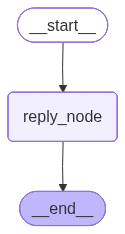

In [ ]:
workflow = StateGraph(ConversationState)

workflow.add_node("reply_node", generate_reply)

workflow.add_edge(START, "reply_node")
workflow.add_edge("reply_node", END)

compiled_agent = workflow.compile()
# Visualization
from IPython.display import Image, display
display(Image(compiled_agent.get_graph().draw_mermaid_png()))

### Step 4 — Introduce External Memory (Conversation Buffer)

Instead of sending a fresh message every time, we now maintain a running history.

In [ ]:
# Stores full conversation across turns
chat_history = []

In [ ]:
chat_history

[]

### Step 5 — Update Interaction Loop (Core Memory Logic)

This is where memory actually becomes active.

In [ ]:
def run_chat():
    """
    This loop:
    - Adds user input to history
    - Sends full history to agent
    - Receives updated history back
    """

    user_text = input("You: ")

    while user_text.lower() != "exit":
        print("CHATHISTORY_before:",chat_history)
        # Add user message to memory
        chat_history.append(HumanMessage(content=user_text))
        print("CHATHISTORY_afterappend:",chat_history)

        # Invoke agent with full memory

        result = compiled_agent.invoke({"messages": chat_history})
        print("AI Message:",result)

        # Update memory with AI response
        chat_history[:] = result["messages"]
        print("CHATHISTORY_afterappend_with_ai:",chat_history)
        user_text = input("You: ")

### Step 6 — Add Persistence (Save to File)

Now we persist the full conversation.

In [ ]:
def save_chat(history):
    """
    Saves conversation into a text file.
    This acts as simple persistence.
    """

    with open("/content/sample_data/conversation_log.txt", "w") as file:
        file.write("Conversation Record:\n\n")

        for msg in history:
            if isinstance(msg, HumanMessage):
                file.write(f"You: {msg.content}\n")
            elif isinstance(msg, AIMessage):
                file.write(f"Assistant: {msg.content}\n\n")

        file.write("---- End ----")

    print("Conversation saved to conversation_log.txt")

Step 7 — Final Integration (Minimal Change to Original Flow)

In [ ]:
if __name__ == "__main__":
    run_chat()
    save_chat(chat_history)

You: hello i am deepak
CHATHISTORY_before: []
CHATHISTORY_afterappend: [HumanMessage(content='hello i am deepak', additional_kwargs={}, response_metadata={})]

Assistant: Hello, Deepak! How can I assist you today?
CURRENT STATE:  [HumanMessage(content='hello i am deepak', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello, Deepak! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
AI Message: {'messages': [HumanMessage(content='hello i am deepak', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello, Deepak! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}
CHATHISTORY_afterappend_with_ai: [HumanMessage(content='hello i am deepak', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello, Deepak! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
You: i

### Previous LOG:

You: hi

Assistant: Hello! How can I assist you today?
CURRENT STATE:  [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
You: i am vinay

Assistant: Nice to meet you, Vinay! How can I help you today?
CURRENT STATE:  [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i am vinay', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Vinay! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
You: My Favorite colour is orange

Assistant: That's a vibrant choice! Orange is often associated with energy and enthusiasm. What do you like most about the color orange?
CURRENT STATE:  [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i am vinay', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Vinay! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='My Favorite colour is orange', additional_kwargs={}, response_metadata={}), AIMessage(content="That's a vibrant choice! Orange is often associated with energy and enthusiasm. What do you like most about the color orange?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
You: i love playing badminton

Assistant: Badminton is a fantastic sport! It’s great for improving agility and reflexes. Do you play it often? Are you part of a club or team?
CURRENT STATE:  [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i am vinay', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Vinay! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='My Favorite colour is orange', additional_kwargs={}, response_metadata={}), AIMessage(content="That's a vibrant choice! Orange is often associated with energy and enthusiasm. What do you like most about the color orange?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i love playing badminton', additional_kwargs={}, response_metadata={}), AIMessage(content='Badminton is a fantastic sport! It’s great for improving agility and reflexes. Do you play it often? Are you part of a club or team?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
You: whats my favoirite colour

Assistant: Your favorite color is orange! Would you like to share more about why you love it?
CURRENT STATE:  [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i am vinay', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Vinay! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='My Favorite colour is orange', additional_kwargs={}, response_metadata={}), AIMessage(content="That's a vibrant choice! Orange is often associated with energy and enthusiasm. What do you like most about the color orange?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i love playing badminton', additional_kwargs={}, response_metadata={}), AIMessage(content='Badminton is a fantastic sport! It’s great for improving agility and reflexes. Do you play it often? Are you part of a club or team?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='whats my favoirite colour', additional_kwargs={}, response_metadata={}), AIMessage(content='Your favorite color is orange! Would you like to share more about why you love it?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
You: what sports do i play

Assistant: You mentioned that you love playing badminton. Do you play any other sports as well?
CURRENT STATE:  [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i am vinay', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Vinay! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='My Favorite colour is orange', additional_kwargs={}, response_metadata={}), AIMessage(content="That's a vibrant choice! Orange is often associated with energy and enthusiasm. What do you like most about the color orange?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='i love playing badminton', additional_kwargs={}, response_metadata={}), AIMessage(content='Badminton is a fantastic sport! It’s great for improving agility and reflexes. Do you play it often? Are you part of a club or team?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='whats my favoirite colour', additional_kwargs={}, response_metadata={}), AIMessage(content='Your favorite color is orange! Would you like to share more about why you love it?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='what sports do i play', additional_kwargs={}, response_metadata={}), AIMessage(content='You mentioned that you love playing badminton. Do you play any other sports as well?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
You: exit
Conversation saved to conversation_log.txt

### Combined L M

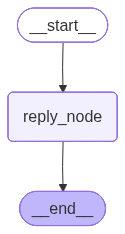

You: exit
Conversation saved to conversation_log.txt


In [ ]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage

class ConversationState(TypedDict):
    """
    State now stores full conversation (not just user input).
    This enables memory.
    """
    messages: List[Union[HumanMessage, AIMessage]]

# ============================
# Initialize LLM
# ============================
chat_model = ChatOpenAI(model="gpt-4o-mini")

def generate_reply(state: ConversationState) -> ConversationState:
    """
    Node now:
    1. Reads full conversation
    2. Generates response
    3. Appends AI response back into state
    """

    result = chat_model.invoke(state["messages"])

    # Store AI response → enables memory
    state["messages"].append(AIMessage(content=result.content))

    print("\nAssistant:", result.content)
    print("CURRENT STATE: ", state["messages"])

    return state

workflow = StateGraph(ConversationState)

workflow.add_node("reply_node", generate_reply)

workflow.add_edge(START, "reply_node")
workflow.add_edge("reply_node", END)

compiled_agent = workflow.compile()
# Visualization
from IPython.display import Image, display
display(Image(compiled_agent.get_graph().draw_mermaid_png()))

# Stores full conversation across turns
chat_history = []

def run_chat():
    """
    This loop:
    - Adds user input to history
    - Sends full history to agent
    - Receives updated history back
    """

    user_text = input("You: ")

    while user_text.lower() != "exit":

        # Add user message to memory
        chat_history.append(HumanMessage(content=user_text))

        # Invoke agent with full memory
        result = compiled_agent.invoke({"messages": chat_history})


        # Update memory with AI response
        chat_history[:] = result["messages"]

        user_text = input("You: ")

def save_chat(history):
    """
    Saves conversation into a text file.
    This acts as simple persistence.
    """

    with open("/content/sample_data/conversation_log.txt", "w") as file:
        file.write("Conversation Record:\n\n")

        for msg in history:
            if isinstance(msg, HumanMessage):
                file.write(f"You: {msg.content}\n")
            elif isinstance(msg, AIMessage):
                file.write(f"Assistant: {msg.content}\n\n")
        file.write("---- End ----")

    print("Conversation saved to conversation_log.txt")

if __name__ == "__main__":
    run_chat()
    save_chat(chat_history)


## Exercise

## Tools
**L : LLM** <br>
**M : Memory: Short Term, Long Term**<br>
**T : Tool : Local, API, MCP**<br>
K : Knowledge Base: RAG<br>

In [ ]:
!pip install langchain-mcp-adapters

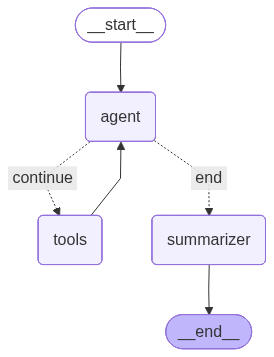

================================ Human Message =================================

Add 40 + 12, multiply by 6, then search latest AI news and suggest a fa flight from Bengaluru to Delhi on 23/06/2026
CURRENT STATE:  [HumanMessage(content='Add 40 + 12, multiply by 6, then search latest AI news and suggest a fa flight from Bengaluru to Delhi on 23/06/2026', additional_kwargs={}, response_metadata={}, id='8f11c99e-af3a-4b99-97e4-82aaaea222fe')]
================================== Ai Message ==================================
Tool Calls:
  add (call_OHpJ71SsiOHZKAMoTfRv37U6)
 Call ID: call_OHpJ71SsiOHZKAMoTfRv37U6
  Args:
    a: 40
    b: 12
  web_search (call_tMZOceYsJdSTEA7OA9lUyLz2)
 Call ID: call_tMZOceYsJdSTEA7OA9lUyLz2
  Args:
    query: latest AI news
  search-flight (call_lM7ujHLRnartLQNFSrQcuFeC)
 Call ID: call_lM7ujHLRnartLQNFSrQcuFeC
  Args:
    flyFrom: Bengaluru
    flyTo: Delhi
    departureDate: 23/06/2026
    departureDateFlexRange: 0
================================= Tool Me

In [ ]:
# ============================================================
# 1. Imports and Setup
# ============================================================

from typing import Annotated, Sequence, TypedDict, Dict, Any
# from dotenv import load_dotenv

# Core message types
from langchain_core.messages import BaseMessage, SystemMessage, AIMessage, HumanMessage

# Tool-related imports
from langchain_core.tools import tool
from langchain.tools import tool as legacy_tool  # for Tavily compatibility

# LLM
from langchain_openai import ChatOpenAI

# Graph components
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# External API tool (Tavily)
from tavily import TavilyClient

# MCP Client
from langchain_mcp_adapters.client import MultiServerMCPClient

# load_dotenv()


# ============================================================
# 2. State Definition (Memory)
# ============================================================

class AgentState(TypedDict):
    """
    This state stores the full conversation.
    add_messages automatically appends messages.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]


# ============================================================
# 3. Local Tools (Math Tools)
# ============================================================

@tool
def add(a: int, b: int):
    """Add two numbers"""
    return a + b

@tool
def subtract(a: int, b: int):
    """Subtract two numbers"""
    return a - b

@tool
def multiply(a: int, b: int):
    """Multiply two numbers"""
    return a * b


# ============================================================
# 4. API Tool (Web Search using Tavily)
# ============================================================
from tavily import TavilyClient

tavily_client = TavilyClient(TAVILY_API_KEY)

@legacy_tool
def web_search(query: str) -> Dict[str, Any]:
    """
    Search the web for real-time information.
    Useful for answering current events or unknown facts.
    """
    return tavily_client.search(query)


# ============================================================
# 5. MCP Tool Integration (External Tool Server)
# ============================================================

import asyncio

async def load_mcp_tools():
    """
    Connects to external MCP server and fetches tools.
    Example: travel APIs, booking systems, etc.
    """
    client = MultiServerMCPClient(

                                    {
        "travel_server": {
                "transport": "streamable_http",
                "url": "https://mcp.kiwi.com"
            }
    }
        # {
        #     "travel_server": {
        #         "transport": "streamable_http",
        #         "url": "https://mcp.kiwi.com"
        #     }
        # }
    )

    return await client.get_tools()


# Load MCP tools synchronously for simplicity
mcp_tools = await load_mcp_tools()


# ============================================================
# 6. Combine All Tools
# ============================================================

tools = [add, subtract, multiply, web_search] + mcp_tools # since mcp_tools is a list


# ============================================================
# 7. Model Binding
# ============================================================

model = ChatOpenAI(model="gpt-4o").bind_tools(tools)


# ============================================================
# 8. Core Agent Node (LLM Call)
# ============================================================

def model_call(state: AgentState) -> AgentState:
    """
    This node:
    - Sends conversation to LLM
    - LLM decides whether to call tools
    """

    system_prompt = SystemMessage(
        content="You are an intelligent AI assistant. Use tools when required."
    )

    response = model.invoke([system_prompt] + list(state["messages"]))
    print("CURRENT STATE: ", state["messages"])
    return {"messages": [response]}


# ============================================================
# 9. Tool Execution Decision Logic
# ============================================================

def should_continue(state: AgentState):
    """
    Checks whether the LLM wants to call a tool.
    """

    # Get the last message from the conversation history
    # This is usually the most recent response from the LLM
    last_message = state["messages"][-1]

    # Safely check if the last message contains any tool calls
    # getattr is used to avoid errors if 'tool_calls' attribute does not exist
    # If 'tool_calls' is missing, it returns None
    if not getattr(last_message, "tool_calls", None):
        # No tool calls found → LLM has given a final answer
        # Signal the workflow to stop
        return "end"
    else:
        # Tool calls exist → LLM wants to use a tool
        # Signal the workflow to continue to the tool execution step
        return "continue"


# ============================================================
# 10. Summarization Node (Memory Compression)
# ============================================================

def summarize_conversation(state: AgentState) -> AgentState:
    """
    Compress conversation when it becomes too long.
    Prevents token overflow.
    """

    MAX_MESSAGES = 10

    if len(state["messages"]) > MAX_MESSAGES:

        print("\n[Summarizing memory...]")

        summary_prompt = [
            HumanMessage(content="Summarize this conversation briefly:")
        ] + list(state["messages"])

        summary = model.invoke(summary_prompt)

        # Replace history with summary + last message
        state["messages"] = [
            AIMessage(content=f"Summary: {summary.content}"),
            state["messages"][-1]
        ]

    return state


# ============================================================
# 11. Build Graph
# ============================================================

graph = StateGraph(AgentState)

# Nodes
graph.add_node("agent", model_call)
graph.add_node("tools", ToolNode(tools=tools))
graph.add_node("summarizer", summarize_conversation)

# Entry point
graph.set_entry_point("agent")

# Conditional flow
graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "end": "summarizer",
    },
)

# After tool execution → go back to agent
graph.add_edge("tools", "agent")

# After summarization → end
graph.add_edge("summarizer", END)

# Compile
app = graph.compile()
# Visualization
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

# ============================================================
# 12. Streaming Output Helper
# ============================================================

def print_stream(stream):
    """
    Pretty prints responses step-by-step.
    Useful for debugging and teaching.
    """

    for step in stream:
        message = step["messages"][-1]

        if hasattr(message, "pretty_print"):
            message.pretty_print()
        else:
            print(message)


# ============================================================
# 13. Run Example
# ============================================================

inputs = {
    "messages": [
        ("user", "Add 40 + 12, multiply by 6, then search latest AI news and suggest a fa flight from Bengaluru to Delhi on 23/06/2026")
    ]
}

import asyncio

async def run_agent():
    async for step in app.astream(inputs, stream_mode="values"):
        message = step["messages"][-1]
        if hasattr(message, "pretty_print"):
            message.pretty_print()
        else:
            print(message)

await run_agent()


# ============================================================
# 12. Interactive Chat Loop (Async + Streaming)
# ============================================================

# async def chat():
#     """
#     Interactive chat loop:
#     - Takes user input
#     - Sends to agent
#     - Streams responses
#     - Maintains conversation memory
#     """

#     print("Type 'exit' to stop\n")

#     # Memory (persists across turns)
#     state = {"messages": []}

#     while True:
#         user_input = input("You: ")

#         if user_input.lower() == "exit":
#             print("Chat ended.")
#             break

#         # Add user message to state
#         state["messages"].append(("user", user_input))

#         print("\n--- Agent Thinking ---")

#         # Stream execution
#         async for step in app.astream(state, stream_mode="values"):
#             message = step["messages"][-1]

#             # Pretty print messages (LLM / Tool / MCP)
#             if hasattr(message, "pretty_print"):
#                 message.pretty_print()
#             else:
#                 print(message)

#         print("\n----------------------\n")


# # ============================================================
# # 13. Run Chat (Notebook-safe)
# # ============================================================

# await chat()

## RAG KB

L : LLM<br>
M : Memory: Short Term, Long Term<br>
T : Tool : Local, API, MCP<br>
K : Knowledge Base: RAG<br>

In [ ]:
!pip install langchain-text-splitters

In [ ]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.6/346.6 kB 11.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. Imports and Setup
# ============================================================

from typing import Annotated, Sequence, TypedDict, Dict, Any
# from dotenv import load_dotenv

# Core message types
from langchain_core.messages import BaseMessage, SystemMessage, AIMessage, HumanMessage

# Tool-related imports
from langchain_core.tools import tool
from langchain.tools import tool as legacy_tool  # for Tavily compatibility

# LLM
from langchain_openai import ChatOpenAI

# Graph components
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# External API tool (Tavily)
from tavily import TavilyClient

# MCP Client
# from langchain_mcp_adapters.client import MultiServerMCPClient

In [ ]:
from langchain_core.tools import tool

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf")

data = loader.load()

print(data)

/tmp/ipykernel_33197/949770612.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2025-11-20T23:23:16+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2025-11-20T23:23:16+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Employee Handbook\nNon-Disclosure Agreement (NDA) Policy\nEmployees must protect confidential information belonging to the company, its clients, and partners.\nThis includes, but is not limited to, product roadmaps, customer data, internal communications,\nproprietary algorithms, financial information, and unreleased features. Confidential information may not\nbe shared with unauthorized individuals inside or outside the organization. These obligations continue\nafter employment ends.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, add_start_index=True
)
all_splits = text_splitter.split_documents(data)

print(len(all_splits))

3


In [ ]:
all_splits

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2025-11-20T23:23:16+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2025-11-20T23:23:16+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'start_index': 0}, page_content='Employee Handbook\nNon-Disclosure Agreement (NDA) Policy\nEmployees must protect confidential information belonging to the company, its clients, and partners.\nThis includes, but is not limited to, product roadmaps, customer data, internal communications,\nproprietary algorithms, financial information, and unreleased features. Confidential information may not\nbe shared with unauthorized individuals inside or outside the organization. These obligations continue\nafte

In [ ]:
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-large",api_key=OPENAI_API_KEY)

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore
vector_store = InMemoryVectorStore(embeddings)
ids = vector_store.add_documents(documents=all_splits)

In [ ]:
# from langchain_community.document_loaders import PyPDFLoader

# loader = PyPDFLoader("https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf")

# data = loader.load()

# print(data)

# from langchain_text_splitters import RecursiveCharacterTextSplitter

# text_splitter = RecursiveCharacterTextSplitter(
#     chunk_size=1000, chunk_overlap=200, add_start_index=True
# )
# all_splits = text_splitter.split_documents(data)

# print(len(all_splits))

# from langchain_openai import OpenAIEmbeddings

# embeddings = OpenAIEmbeddings(model="text-embedding-3-large",api_key=OPENAI_API_KEY)


# from langchain_core.vectorstores import InMemoryVectorStore

# vector_store = InMemoryVectorStore(embeddings)

# ids = vector_store.add_documents(documents=all_splits)



[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2025-11-20T23:23:16+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2025-11-20T23:23:16+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Employee Handbook\nNon-Disclosure Agreement (NDA) Policy\nEmployees must protect confidential information belonging to the company, its clients, and partners.\nThis includes, but is not limited to, product roadmaps, customer data, internal communications,\nproprietary algorithms, financial information, and unreleased features. Confidential information may not\nbe shared with unauthorized individuals inside or outside the organization. These obligations continue\nafter employment ends.

In [ ]:
results = vector_store.similarity_search(
    "How many days of vacation does an employee get in their first year?"
)
print(results[0])

page_content='prohibited. Violations may result in disciplinary action.
Paid Time Off (PTO) Policy
Full■time employees accrue PTO according to the following schedule:  0–1 years of service: 10 days
per year (0.833 days per month)  1–3 years of service: 15 days per year (1.25 days per month)  3+
years of service: 20 days per year (1.67 days per month) PTO may be used for vacation, personal
needs, or illness. Requests should be submitted in advance through the HR system unless related to
an emergency. Employees may carry over up to 5 unused PTO days per calendar year. Extended
absences exceeding 5 consecutive business days require manager approval.
Travel & Expense Policy
Employees may be reimbursed for reasonable and necessary expenses incurred during approved
business travel. This includes transportation, lodging, meals, and incidental expenses within
established limits. Receipts must be submitted within 14 days of travel. First-class travel, personal' metadata={'producer': 'ReportL

In [ ]:
results = vector_store.similarity_search(
    "confidential"
)
print(results[0])

page_content='Employee Handbook
Non-Disclosure Agreement (NDA) Policy
Employees must protect confidential information belonging to the company, its clients, and partners.
This includes, but is not limited to, product roadmaps, customer data, internal communications,
proprietary algorithms, financial information, and unreleased features. Confidential information may not
be shared with unauthorized individuals inside or outside the organization. These obligations continue
after employment ends.
Workplace Conduct Policy
Employees must maintain a respectful, professional environment free from harassment, discrimination,
and intimidation. All employees are expected to follow organizational values, collaborate effectively,
and communicate constructively. Disruptive behavior, verbal abuse, or misuse of company systems is
prohibited. Violations may result in disciplinary action.
Paid Time Off (PTO) Policy
Full■time employees accrue PTO according to the following schedule:  0–1 years of servic

In [ ]:
results = vector_store.similarity_search(
    "confidential terms shall not be discussed beyond office"
)
print(results[0])

page_content='Employee Handbook
Non-Disclosure Agreement (NDA) Policy
Employees must protect confidential information belonging to the company, its clients, and partners.
This includes, but is not limited to, product roadmaps, customer data, internal communications,
proprietary algorithms, financial information, and unreleased features. Confidential information may not
be shared with unauthorized individuals inside or outside the organization. These obligations continue
after employment ends.
Workplace Conduct Policy
Employees must maintain a respectful, professional environment free from harassment, discrimination,
and intimidation. All employees are expected to follow organizational values, collaborate effectively,
and communicate constructively. Disruptive behavior, verbal abuse, or misuse of company systems is
prohibited. Violations may result in disciplinary action.
Paid Time Off (PTO) Policy
Full■time employees accrue PTO according to the following schedule:  0–1 years of servic

In [ ]:
results = vector_store.similarity_search(
    "reimbursable"
)
print(results[0])

page_content='business travel. This includes transportation, lodging, meals, and incidental expenses within
established limits. Receipts must be submitted within 14 days of travel. First-class travel, personal
expenses, and non-business activities are not reimbursable. Employees should exercise good
judgment and cost-effective decision-making when traveling on behalf of the company.' metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2025-11-20T23:23:16+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2025-11-20T23:23:16+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'start_index': 1571}


In [ ]:
retriever = vector_store.as_retriever()

In [ ]:
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information from the https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf document.
    """

    docs = retriever.invoke(query)

    if not docs:
        return "I found no relevant information in Employee Handbook."

    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")

    return "\n\n".join(results)

In [ ]:
tools = [retriever_tool]

In [ ]:
llm = llm.bind_tools(tools)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

In [ ]:
system_prompt = """
You are an intelligent AI assistant who answers questions about employee from PDF document loaded into your knowledge base called employee handbook.
Use the retriever tool available to answer questions about the following:
Non-Disclosure Agreement (NDA) Policy
Workplace Conduct Policy
Paid Time Off (PTO) Policy
Travel & Expense Policy
You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific parts of the documents you use in your answers.
"""


In [ ]:
tools_dict = {our_tool.name: our_tool for our_tool in tools} # Creating a dictionary of our tools

In [ ]:
# LLM Agent
def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""

    # Convert state messages (could be tuple/immutable) into a list for manipulation
    messages = list(state['messages'])


    # Prepend the system prompt to guide LLM behavior
    # SystemMessage defines instructions like "you are a helpful assistant"
    messages = [SystemMessage(content=system_prompt)] + messages

    # Call the LLM with the prepared messages
    # This returns an AIMessage (which may include tool_calls)
    message = llm.invoke(messages)

    # Return the new message wrapped inside state format
    # IMPORTANT: Only returning the new message (not full history)
    return {'messages': [message]}


# Retriever Agent
def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""


    # Extract tool calls from the last LLM message
    # This assumes the LLM has already decided which tools to call
    tool_calls = state['messages'][-1].tool_calls

    # Store results of all tool executions
    results = []

    # Loop through each tool call requested by the LLM
    for t in tool_calls:

        # Debug print: which tool is being called and with what query
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")


        # Check if the requested tool exists in the available tools dictionary
        if not t['name'] in tools_dict: # Checks if a valid tool is present

            # If tool is invalid, log error
            print(f"\nTool: {t['name']} does not exist.")

            # Return a fallback response for the LLM
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."

        else:
            # If tool exists → invoke it with the provided query
            # t['args'] typically contains parameters like {"query": "..."}
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))

            # Debug print: size of tool output (useful for large responses)
            print(f"Result length: {len(str(result))}")


        # Appends the Tool Message
        # Wrap tool result into a ToolMessage
        # tool_call_id links this result to the original tool request
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))


    # Debug print indicating tool execution phase is complete
    print("Tools Execution Complete. Back to the model!")

    # Return tool results as new messages
    # These will be fed back into the LLM in the next step
    return {'messages': results}

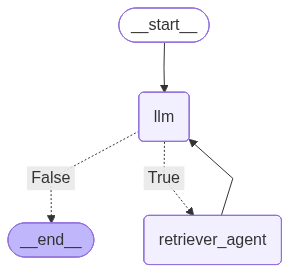

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)

graph.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")

rag_agent = graph.compile()
# Visualization
from IPython.display import Image, display
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import ToolMessage

In [ ]:
def running_agent():
    print("\n=== RAG AGENT===")

    while True:
        user_input = input("\nWhat is your question: ")
        if user_input.lower() in ['exit', 'quit']:
            break

        messages = [HumanMessage(content=user_input)] # converts back to a HumanMessage type

        result = rag_agent.invoke({"messages": messages})

        print("\n=== ANSWER ===")
        print(result['messages'][-1].content)


running_agent()


=== RAG AGENT===

What is your question: how many leaves we get in 1st year
Calling Tool: retriever_tool with query: Paid Time Off (PTO) Policy
Result length: 2361
Tools Execution Complete. Back to the model!

=== ANSWER ===
In the first year of service, employees accrue 10 days of Paid Time Off (PTO). This translates to approximately 0.833 days per month. This policy allows employees to use PTO for vacation, personal needs, or illness, with certain carry-over and request submission guidelines as specified in the handbook.

What is your question: is transportation, lodging, meals, included in or reimbursed 
Calling Tool: retriever_tool with query: Travel & Expense Policy transportation lodging meals reimbursement
Result length: 2361
Tools Execution Complete. Back to the model!

=== ANSWER ===
Yes, transportation, lodging, meals, and incidental expenses are included in the Travel & Expense Policy for reimbursement during approved business travel. However, these expenses must fall withi

KeyboardInterrupt: Interrupted by user

## Pydantic Validators

In [ ]:
!pip install langgraph langchain pydantic ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.5 MB/s eta 0:00:00


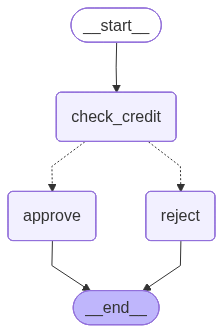

In [ ]:
# Imports
from pydantic import BaseModel, field_validator, ValidationError
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# -----------------------------
# 1. Define State with Validation
# -----------------------------
class LoanApplication(BaseModel):
    applicant_name: str
    credit_score: int   # must be between 300 and 850
    loan_amount: float  # must be > 0

    @field_validator('credit_score')
    @classmethod
    def validate_credit_score(cls, value):
        if value < 300 or value > 850:
            raise ValueError("Credit score must be between 300 and 850")
        return value

    @field_validator('loan_amount')
    @classmethod
    def validate_loan_amount(cls, value):
        if value <= 0:
            raise ValueError("Loan amount must be greater than 0")
        return value


# -----------------------------
# 2. Define Nodes
# -----------------------------
def check_credit(state: LoanApplication):
    print(f"Checking credit score for {state.applicant_name}")
    return state

def approve_loan(state: LoanApplication):
    print(f"Loan APPROVED for {state.applicant_name}")
    return state

def reject_loan(state: LoanApplication):
    print(f"Loan REJECTED for {state.applicant_name}")
    return state


# -----------------------------
# 3. Conditional Logic
# -----------------------------
def decide_approval(state: LoanApplication):
    if state.credit_score >= 650:
        return "approve"
    else:
        return "reject"


# -----------------------------
# 4. Build Graph
# -----------------------------
builder = StateGraph(LoanApplication)

builder.add_node("check_credit", check_credit)
builder.add_node("approve", approve_loan)
builder.add_node("reject", reject_loan)

builder.add_edge(START, "check_credit")

builder.add_conditional_edges(
    "check_credit",
    decide_approval,
    {
        "approve": "approve",
        "reject": "reject"
    }
)

builder.add_edge("approve", END)
builder.add_edge("reject", END)

graph = builder.compile()


# -----------------------------
# 5. Visualize Graph
# -----------------------------
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
# -----------------------------
# 6. Valid Input (Works)
# -----------------------------
print("\n--- VALID INPUT ---")
valid_state = LoanApplication(
    applicant_name="Vinay",
    credit_score=720,
    loan_amount=500000
)

graph.invoke(valid_state)


--- VALID INPUT ---
Checking credit score for Vinay
Loan APPROVED for Vinay


{'applicant_name': 'Vinay', 'credit_score': 720, 'loan_amount': 500000.0}

In [ ]:
invalid_state = LoanApplication(
        applicant_name="John",
        credit_score=400,  # ❌ invalid
        loan_amount=300000
    )

In [ ]:
# -----------------------------
# 7. Invalid Input (Blocked)
# -----------------------------
print("\n--- INVALID INPUT (credit_score) ---")
try:
    invalid_state = LoanApplication(
        applicant_name="John",
        credit_score=200,  # ❌ invalid
        loan_amount=300000
    )
except ValidationError as e:
    print("Validation Error:", e)


--- INVALID INPUT (credit_score) ---
Validation Error: 1 validation error for LoanApplication
credit_score
  Value error, Credit score must be between 300 and 850 [type=value_error, input_value=200, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error


In [ ]:
print("\n--- INVALID INPUT (loan_amount) ---")
try:
    invalid_state = LoanApplication(
        applicant_name="Alice",
        credit_score=700,
        loan_amount=-1000  # ❌ invalid
    )
except ValidationError as e:
    print("Validation Error:", e)


--- INVALID INPUT (loan_amount) ---
Validation Error: 1 validation error for LoanApplication
loan_amount
  Value error, Loan amount must be greater than 0 [type=value_error, input_value=-1000, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error


## Reducer Logic

In [ ]:
!pip install -U langchain openai langchain-openai langchain_community tavily-python langsmith  wikipedia

In [ ]:
from google.colab import userdata
# Required for model usage
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')
TAVILY_API_KEY=userdata.get('tavily_key')
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

import os
from google.colab import userdata

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# Set your LangChain API key
os.environ["LANGCHAIN_API_KEY"] = userdata.get("langsmith_key")

# Enable Langsmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = "true"

# Set the Langsmith project name
os.environ["LANGCHAIN_PROJECT"] = "QC_Tutorial"

print("Environment variables set for OpenAI API Key, LangChain API Key, Langsmith Tracing, and Langsmith Project.")

Environment variables set for OpenAI API Key, LangChain API Key, Langsmith Tracing, and Langsmith Project.


In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")
llm.invoke("What is Agent?")

AIMessage(content='The term "agent" can have several meanings depending on the context in which it is used. Here are a few common definitions:\n\n1. **General Definition**: An agent is typically someone or something that acts on behalf of another person or entity. This can include representatives, intermediaries, or individuals authorized to make decisions or take actions for others.\n\n2. **Business Context**: In business, an agent might refer to a person or company that represents another entity in transactions. For example, a real estate agent represents buyers or sellers in property transactions.\n\n3. **Software/Technology**: In computer science, particularly in artificial intelligence, an agent can refer to an autonomous entity that observes its environment and takes actions to achieve specific goals. This can include software agents, robotic agents, or intelligent agents.\n\n4. **Legal Context**: In law, an agent is someone who is authorized to act on behalf of another person, k

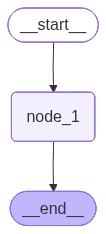

In [ ]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"foo" : 1})

---Node 1---


{'foo': 2}

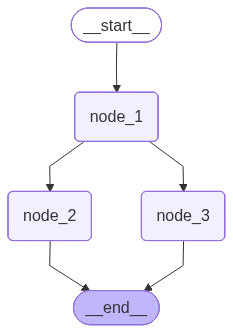

In [ ]:
class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

def node_2(state):
    print("---Node 2---")
    return {"foo": state['foo'] + 1}

def node_3(state):
    print("---Node 3---")
    return {"foo": state['foo'] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"foo" : 1})

---Node 1---
---Node 2---
---Node 3---


InvalidUpdateError: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [ ]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"foo" : 1})
except InvalidUpdateError as e:
    print(f"InvalidUpdateError occurred: {e}")


---Node 1---
---Node 2---
---Node 3---
InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


### Reducers

Reducer give us a general way to address this problem.

They specify how to perform updates.

We can use the `Annotated` type to specify a reducer function.

For example, in this case let's append the value returned from each node rather than overwriting them.

We just need a reducer that can perform this: `operator.add` is a function from Python's built-in operator module.

When `operator.add` is applied to lists, it performs list concatenation.

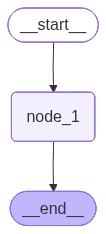

In [ ]:
from operator import add
from typing import Annotated

class State(TypedDict):
    foo: Annotated[list[int], add]

def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][0] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"foo" : [1]})

---Node 1---


{'foo': [1, 2]}

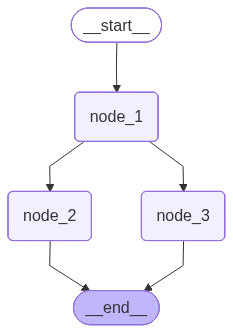

In [ ]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][-1] + 1]}

def node_2(state):
    print("---Node 2---")
    return {"foo": [state['foo'][-1] + 1]}

def node_3(state):
    print("---Node 3---")
    return {"foo": [state['foo'][-1] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"foo" : [1]})

---Node 1---
---Node 2---
---Node 3---


{'foo': [1, 2, 3, 3]}

## Schema Modifications

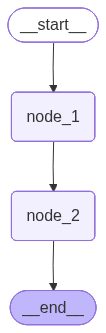

In [ ]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class OverallState(TypedDict):
    foo: int # 1, 3

class PrivateState(TypedDict):
    baz: int # 2


# def node_1(state: OverallState) -> OverallState:
#     print("---Node 1---")
#     return {"foo": state['foo'] + 1}


def node_1(state: OverallState) -> PrivateState:
    print("---Node 1---")
    return {"baz": state['foo'] + 1}

def node_2(state: PrivateState) -> OverallState:
    print("---Node 2---")
    return {"foo": state['baz'] + 1}

# Build graph
builder = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"foo" : 1})

---Node 1---
---Node 2---


{'foo': 3}

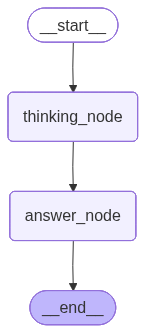

In [ ]:
class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: OverallState):
    return {"answer": "bye", "notes": "... his name is Lance"}

def answer_node(state: OverallState):
    return {"answer": "bye Lance"}

graph = StateGraph(OverallState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"question":"hi"})

{'question': 'hi', 'answer': 'bye Lance', 'notes': '... his name is Lance'}

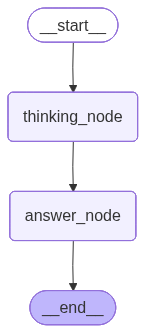

{'answer': 'bye Lance'}

In [ ]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"answer": "bye", "notes": "... his is name is Lance"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "bye Lance"}

graph = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question":"hi"})

## Tool Call and Condition Details

In [ ]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")

# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

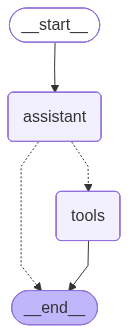

In [ ]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
# builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2.Add 3 again. Divide the output by 5 and add 3 to the final output")]
messages = react_graph.invoke({"messages": messages})

In [ ]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2.Add 3 again. Divide the output by 5 and add 3 to the final output
================================== Ai Message ==================================
Tool Calls:
  add (call_twH00edEwUxxx331xSMdFnFz)
 Call ID: call_twH00edEwUxxx331xSMdFnFz
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7


In [ ]:
messages = [HumanMessage(content="Add 4 and 5.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 4 and 5.
================================== Ai Message ==================================
Tool Calls:
  add (call_t1sVKd5ICCDbjIdRu7PIXJgr)
 Call ID: call_t1sVKd5ICCDbjIdRu7PIXJgr
  Args:
    a: 4
    b: 5
================================= Tool Message =================================
Name: add

9


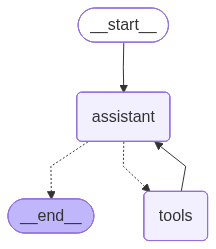

In [ ]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2.Add 3 again. Divide the output by 5 and add 3 to the final output")]
messages = react_graph.invoke({"messages": messages})

In [ ]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2.Add 3 again. Divide the output by 5 and add 3 to the final output
================================== Ai Message ==================================
Tool Calls:
  add (call_CdDlxKoOzFkQeDYJS4s515yP)
 Call ID: call_CdDlxKoOzFkQeDYJS4s515yP
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (call_Cmq8bZJ846xqkksYzJOLzEzB)
 Call ID: call_Cmq8bZJ846xqkksYzJOLzEzB
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  add (call_3VaRAdCEazsC0xObcxcfIKDG)
 Call ID: call_3VaRAdCEazsC0xObcxcfIKDG
  Args:
    a: 14
    b: 3
=======================

Revisit

In [ ]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools([multiply])

In [ ]:
import random

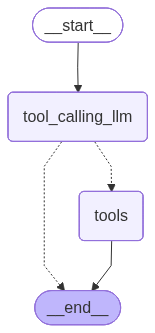

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
'''tools_condition: This utility function implements the standard conditional logic for ReAct-style
    agents: if the last `AIMessage` contains tool calls, route to the tool execution
    node; otherwise, end the workflow. This pattern is fundamental to most tool-calling
    agent architectures.'''

# Node
def tool_calling_llm(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    print("LLM Response:", response)
    return {"messages": [response]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #in this "Hello, what is 2 multiplied by 2?" a tool call is required and returned by assistant so it will do tool call
    #in this "Hello, what is it" not tool call is required or suggested by assitant so no tool call will happen
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
# builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

LLM Response: content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 63, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cf3486f145', 'id': 'chatcmpl-DNKsQk40457xIKm8JcdhZrlae15l6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d25b5-d2ce-7d21-8390-3c4f40ebdd79-0' tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'call_vulqDNd7WggimNw6yjrKhUjl', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 63, 'output_tokens': 17, 'total_tokens': 80, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
===========================

In [ ]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is it")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

LLM Response: content='Hello! How can I assist you today?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 57, 'total_tokens': 67, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cf3486f145', 'id': 'chatcmpl-DNKsXKKh471Rt6RfwrhGAja9VfLXJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d25b5-f08d-7a02-92af-440f7924580f-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 57, 'output_tokens': 10, 'total_tokens': 67, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
================================ Human Message =================================

Hello, what is it
=====

In [ ]:
from typing import Literal
from pprint import pprint
from pprint import PrettyPrinter

pp = PrettyPrinter(width=120, compact=False, indent=2)
from pprint import pprint


def debug_tools_condition(state: MessagesState) -> Literal["tools", "__end__"]:

    print("\n===== DEBUG ROUTER =====")
    print(state["messages"])
    last_message = state["messages"][-1]
    print("Last message type:", type(last_message))
    print(last_message)
    pprint(last_message.response_metadata)
    print("Last message content:", getattr(last_message, "content", None))

    # Check if tool calls exist
    tool_calls = getattr(last_message, "tool_calls", None)
    print(tool_calls)
    if tool_calls:
        print("Tool Calls Detected:", tool_calls)
        print("➡️ Routing to: tools\n")
        return "tools"
    else:
        print("No Tool Calls")
        print("➡️ Routing to: END\n")
        return "__end__"

In [ ]:
def tool_calling_llm(state: MessagesState):
    print("\n--- LLM NODE ---")

    response = llm_with_tools.invoke(state["messages"])

    print("LLM Response:", response)
    pprint(response.response_metadata)

    return {"messages": [response]}

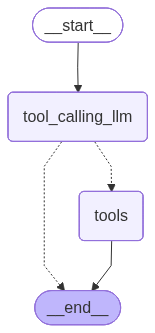

In [ ]:
from IPython.display import Image, display
builder = StateGraph(MessagesState)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))

builder.add_edge(START, "tool_calling_llm")

# 👇 Replace tools_condition with debug version
builder.add_conditional_edges(
    "tool_calling_llm",
    debug_tools_condition
)

builder.add_edge("tools", END)

graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

graph.invoke({
    "messages": [HumanMessage(content="Hello how are you?")]
})



--- LLM NODE ---
LLM Response: content="Hello! I'm here to help, so if you have any questions or need assistance with something, feel free to ask! How can I assist you today?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 57, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1bc4f4a202', 'id': 'chatcmpl-DNJDemNETf1SAyHqUpFDwvUUuLh8V', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d2554-993f-76d2-af97-c204e94a1f02-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 57, 'output_tokens': 32, 'total_tokens': 89, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'rea

{'messages': [HumanMessage(content='Hello how are you?', additional_kwargs={}, response_metadata={}, id='49d3326e-4633-4c36-bb97-1604dea66807'),
  AIMessage(content="Hello! I'm here to help, so if you have any questions or need assistance with something, feel free to ask! How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 57, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1bc4f4a202', 'id': 'chatcmpl-DNJDemNETf1SAyHqUpFDwvUUuLh8V', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d2554-993f-76d2-af97-c204e94a1f02-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 57, 'outp

In [ ]:
graph.invoke({
    "messages": [HumanMessage(content="What is 3 multiplied by 5?")]
})


--- LLM NODE ---
LLM Response: content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 61, 'total_tokens': 78, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1bc4f4a202', 'id': 'chatcmpl-DNJDyIRol0bukoGlKrfaGEUmGFF8s', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d2554-e615-7f72-b446-da8ea27ce8b7-0' tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 5}, 'id': 'call_WWjB5wHd0R7FaSwixk8HpzS1', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 61, 'output_tokens': 17, 'total_tokens': 78, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
{'finish_

{'messages': [HumanMessage(content='What is 3 multiplied by 5?', additional_kwargs={}, response_metadata={}, id='dad321d8-4a8b-498b-a364-84a9c8576892'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 61, 'total_tokens': 78, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_1bc4f4a202', 'id': 'chatcmpl-DNJDyIRol0bukoGlKrfaGEUmGFF8s', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2554-e615-7f72-b446-da8ea27ce8b7-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 5}, 'id': 'call_WWjB5wHd0R7FaSwixk8HpzS1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 61, 'output_tokens': 17

SME(Trainer) : Vinay Kumar (vinay2k2@gmail.com)<br>
Connect with me:
https://www.linkedin.com/in/vinay2k2
